In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from sklearn.cluster import KMeans

from pathlib import Path

import pytz
import datetime as dt

import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
import sys
sys.path.append("../src")

In [4]:
from core import FREQUENCY_COLOR_MAPPINGS
import activity.subsampling as ss
from cli import get_file_paths

In [5]:
def plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params):
    """
    Function to plot the spectrogram of a provided audio segment with overlayed detections
    """

    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    duration = audio_features['duration']

    file_dt = dt.datetime.strptime(audio_features['file_path'].name, '%Y%m%d_%H%M%S.WAV')

    UBNA_tz = pytz.timezone('US/Pacific')
    UTC_tz = pytz.timezone('UTC')

    file_dt_UTC = UTC_tz.localize(file_dt)
    file_dt_PST = file_dt_UTC.astimezone(UBNA_tz)
    file_title = f'{file_dt_PST.date()} {file_dt_PST.time()} PST'

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 24})
    plt.title(f"Audiomoth file recorded at {file_title}", fontsize=22)
    plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmax=0, vmin=spec_features['vmin'])

    orange_patch = patches.Patch(facecolor='orange', edgecolor='k', label='High-frequency calls')
    cyan_patch = patches.Patch(facecolor='lightskyblue', edgecolor='k', label='Low-frequency calls')

    legend_patches = [orange_patch, cyan_patch]
    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=1.5, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=0.8)
        
        ax.add_patch(rect)

    windows_PST = pd.date_range(file_dt_PST+pd.Timedelta(seconds=start), file_dt_PST+pd.Timedelta(seconds=start)+pd.Timedelta(seconds=duration), freq=f'5T', inclusive='both')

    plt.yticks(ticks=np.linspace(0, 1*(96/125), 6), labels=np.linspace(0, 192000/2000, 6).astype('int'))
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), len(windows_PST)), labels=windows_PST.strftime('%H:%M'), color='k', rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (HH:MM)")
    plt.ylim(0, 96/125)
    cbar = plt.colorbar()
    cbar.ax.tick_params(labelsize=16)
    plt.legend(handles=legend_patches, fontsize=20, ncol=1, loc='upper right')

    plt.tight_layout()
    plt.show()

In [11]:
site_key = 'Carp'
freq_key = ''

data_params = dict()
data_params['site_tag'] = site_key
data_params['type_tag'] = freq_key
data_params['det_prob_threshold'] = 0.35
data_params['SNR_threshold'] = 3
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
file_paths = get_file_paths(data_params)

location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', index_col=0)
inds_where_dets_above_detection_probability = location_df['det_prob'].astype(float)>=data_params['det_prob_threshold']
location_df_above_detection_probability = location_df[inds_where_dets_above_detection_probability].copy()
inds_where_dets_above_SNR = location_df_above_detection_probability['SNR'].astype(float)>=data_params['SNR_threshold']
location_df_above_SNR_and_detthresh = location_df_above_detection_probability[inds_where_dets_above_SNR].copy()

files_from_loc = sorted(list(Path(f'../data/audiomoth_recordings/').glob(pattern=f'*/{site_key}/*.WAV')))
file = files_from_loc[11]
file_path = Path(file)
filename = file_path.name
audio_file = sf.SoundFile(file_path)
fs = audio_file.samplerate

file_dt_start = dt.datetime.strptime(filename, '%Y%m%d_%H%M%S.WAV')
file_dt_end = file_dt_start + pd.Timedelta(minutes=30)

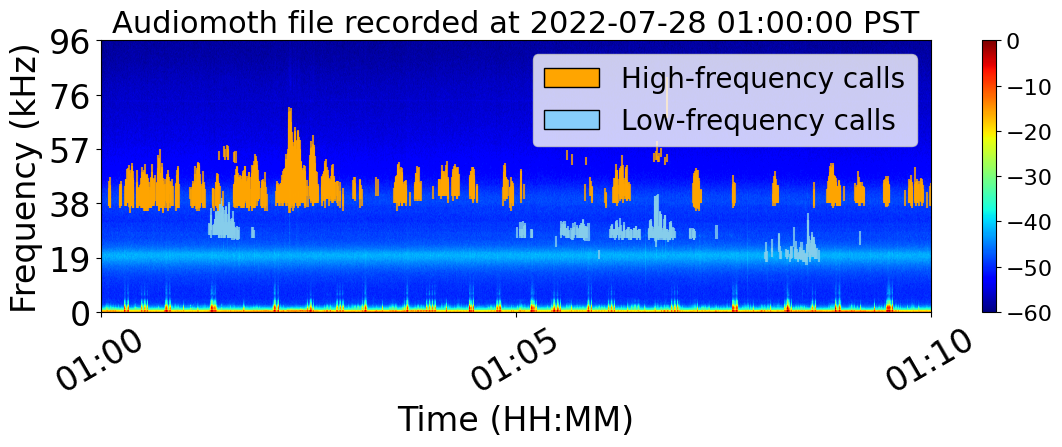

In [12]:
start = 0
duration = 600
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

audio_features = dict()
audio_features['file_path'] = file_path
audio_features['audio_seg'] = audio_seg
audio_features['sample_rate'] = fs
audio_features['start'] = start
audio_features['duration'] = duration
audio_features['figsize'] = (12, 5)

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 1024
spec_features['cmap'] = 'jet'

start_time_bounds = pd.to_datetime(location_df_above_SNR_and_detthresh['call_start_time'])>=file_dt_start
end_time_bounds = pd.to_datetime(location_df_above_SNR_and_detthresh['call_end_time'])<=file_dt_end
plot_dets = location_df_above_SNR_and_detthresh.loc[start_time_bounds&end_time_bounds]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
plot_dets_over_audio_seg(audio_features, spec_features, plot_dets, data_params)

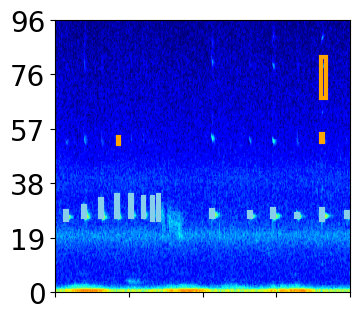

In [22]:
start = 407
duration = 3
plot_dets = location_df_above_SNR_and_detthresh.loc[start_time_bounds&end_time_bounds]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

plt.figure(figsize=(4, 3.6))
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])
ax = plt.gca()
for i, row in plot_dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)

    ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 1*(192000/fs), 6), labels=np.linspace(0, 192/2, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), 5), labels=['']*5, color='k')
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

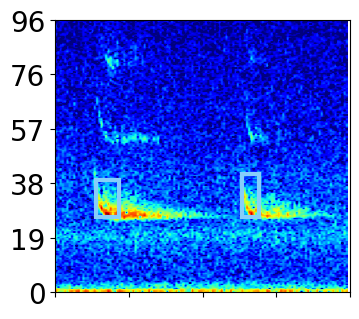

In [7]:
start = 402.14
duration = 0.2
plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

plt.figure(figsize=(4, 3.6))
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])
ax = plt.gca()
for i, row in plot_dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)

    ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 1*(192000/fs), 6), labels=np.linspace(0, 192/2, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), 5), labels=['']*5, color='k')
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

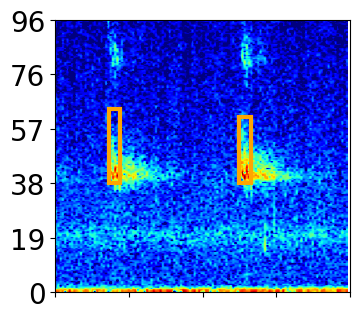

In [8]:
start = 136.61
duration = 0.2
plot_dets = location_df.loc[(pd.to_datetime(location_df['call_start_time'])>=file_dt_start)&(pd.to_datetime(location_df['call_end_time'])<=file_dt_end)]
plot_dets = plot_dets.loc[np.logical_and(plot_dets['start_time'] >= start, plot_dets['end_time'] <= (start+duration))]
audio_file.seek(int(fs*start))
audio_seg = audio_file.read(int(fs*duration))

spec_features = dict()
spec_features['vmax'] = 0 # hide anything above vmax dB
spec_features['vmin'] = -60 # hide anything below vmin dB
spec_features['NFFT'] = 512
spec_features['cmap'] = 'jet'

plt.figure(figsize=(4, 3.6))
plt.rcParams.update({'font.size': 20})
plt.specgram(audio_seg, NFFT=spec_features['NFFT'], cmap=spec_features['cmap'], vmin=spec_features['vmin'])
ax = plt.gca()
for i, row in plot_dets.iterrows():
    rect = patches.Rectangle(((row['start_time'] - start)*(fs/2), row['low_freq']/(fs/2)), 
                    (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                    linewidth=3, edgecolor=FREQUENCY_COLOR_MAPPINGS[row['freq_group']], facecolor='none', alpha=1)
    ax.add_patch(rect)

plt.yticks(ticks=np.linspace(0, 1*(192000/fs), 6), labels=np.linspace(0, 192/2, 6).astype('int'))
plt.xticks(ticks=np.linspace(0, duration*(fs/2), 5), labels=['']*5, color='k')
plt.ylabel("")
plt.xlabel("")
plt.ylim(0, 96/125)

plt.tight_layout()
plt.show()

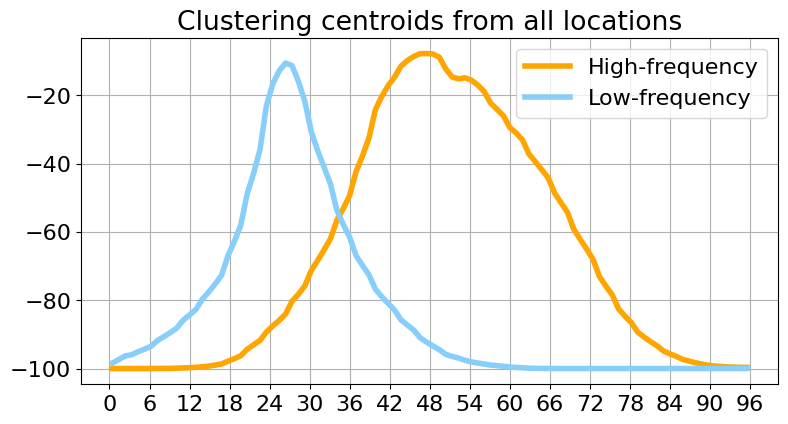

In [9]:
color_for_groups = {0: FREQUENCY_COLOR_MAPPINGS['HF'], 1: FREQUENCY_COLOR_MAPPINGS['LF']}
label_for_groups = {0: 'High-frequency', 1: 'Low-frequency'}

site_key = 'all_locations'
output_dir = Path(f'../data/generated_welch/{site_key}')
if not(output_dir.is_dir()):
    output_dir.mkdir(parents=True)
output_file_type = 'top1_inbouts_welch_signals'

welch_data = pd.read_csv(output_dir / f'2022_{site_key}_{output_file_type}.csv', index_col=0, low_memory=False)
welch_data.columns.name = 'Frequency (Hz)'
welch_data = welch_data[:1000]

k = 2
state = 1500
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=state).fit(welch_data)
plt.figure(figsize=(9, 4.5))
plt.rcParams.update({'font.size':16})
plt.title(f'Clustering centroids from all locations')
for i in range(k):
    plt.plot(kmean_welch.cluster_centers_[i], label=f'{label_for_groups[i]}', color=color_for_groups[i], alpha=1, linewidth=4)
plt.xticks(np.linspace(0, 100, 17)-0.5, np.linspace(0, 96, 17).astype(int), rotation=0)
plt.grid(which='both')
plt.legend(loc='upper right', fontsize=16)
plt.show()

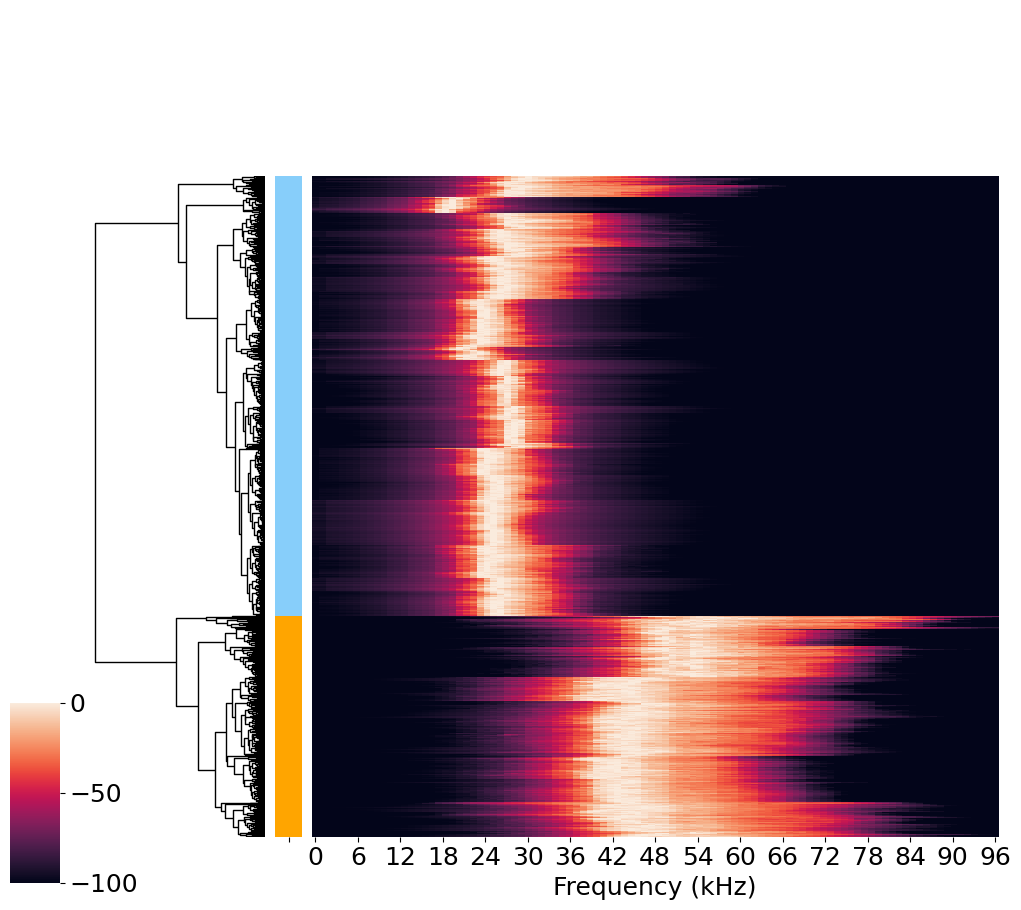

In [10]:
groups = pd.Series(kmean_welch.labels_)
groups_to_labels = groups.map(label_for_groups)
groups_to_colors = groups.map(color_for_groups)
desired_xlabels = np.arange(0, 100, 6)
desired_xticks = (desired_xlabels * (99/96))+0.5

plt.rcParams.update({'font.size':18})
g = sns.clustermap(welch_data, figsize=(10, 10), col_cluster=False, row_colors=groups_to_colors, cbar_pos=(-0.05, 0.1, 0.05, 0.18), yticklabels=False, tree_kws=dict(linewidths=1, colors='k'))
ax = g.ax_heatmap
ax.set_ylabel('')
ax.set_xticks(desired_xticks, desired_xlabels, rotation=0)
ax.set_xlabel('Frequency (kHz)')
plt.show()